In [1]:
import os
# Set environment variables to avoid deadlocks with dataloaders
os.environ["TOKENIZERS_PARALLELISM"] = "false"
# Set this to the GPU you want to use
os.environ["CUDA_VISIBLE_DEVICES"] = "2" 
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from tqdm import tqdm
import json
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import CIFAR100, Food101, Flowers102, DTD, EuroSAT
from transformers import CLIPModel, CLIPProcessor
from peft import PeftModel
import pandas as pd
from sklearn.metrics import accuracy_score, top_k_accuracy_score# Import your helper functions
try:
    from dataset_helpers import (
        FLOWERS102_CLASS_NAMES,
        GENERAL_TEMPLATES,
        DTD_TEMPLATES,
        EUROSAT_TEMPLATES,
        FGVC_TEMPLATES
    )
except ImportError:
    print("Error: dataset_helpers.py not found. Please ensure it is in the same directory.")

In [2]:
# --- REPRODUCIBILITY ---
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# --- CONFIGURATION ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 64
DATA_ROOT = os.path.expanduser("~/.cache")
RESULTS_DIR = "Results"
os.makedirs(RESULTS_DIR, exist_ok=True)
# === USER INPUT: UPDATE THIS PATH ===
# Path to your LoRA adapter trained on MS COCO
LORA_ADAPTER_PATH = "../clip_lora_checkpoints/epoch-3" # Path to your saved LoRA
# LORA_ADAPTER_PATH = "path/to/your/lora/adapter" 
CLIP_MODEL_ID = "openai/clip-vit-base-patch32"

print(f"Running analysis on {DEVICE}")

Running analysis on cuda


In [3]:
# cell_2_model_wrapper.py
class ZeroShotClassifier:
    def __init__(self, base_model_id, lora_path=None):
        self.device = DEVICE
        self.base_model_id = base_model_id
        
        # Load Processor (Handles image resizing/normalization and text tokenization)
        self.processor = CLIPProcessor.from_pretrained(base_model_id)
        
        # Load Model
        base_model = CLIPModel.from_pretrained(base_model_id)
        
        if lora_path and os.path.exists(lora_path):
            print(f"Loading LoRA Adapter from: {lora_path}")
            self.model = PeftModel.from_pretrained(base_model, lora_path)
            self.name = "LORA_CLIP"
        else:
            if lora_path: print(f"Warning: LoRA path {lora_path} not found. Using Base CLIP.")
            self.model = base_model
            self.name = "CLIP"
            
        self.model.to(self.device)
        self.model.eval()

    @torch.no_grad()
    def get_text_features(self, class_names, templates):
        """
        Generates Zero-Shot weights by ensembling templates for each class.
        """
        print(f"[{self.name}] Building text embedding cache for {len(class_names)} classes...")
        zeroshot_weights = []
        
        for classname in tqdm(class_names):
            texts = [template.format(classname) for template in templates]
            
            # Tokenize
            inputs = self.processor(text=texts, return_tensors="pt", padding=True).to(self.device)
            
            # Encode text
            class_embeddings = self.model.get_text_features(**inputs)
            
            # Normalize and Average (Ensembling)
            class_embeddings /= class_embeddings.norm(dim=-1, keepdim=True)
            class_embedding = class_embeddings.mean(dim=0)
            class_embedding /= class_embedding.norm()
            
            zeroshot_weights.append(class_embedding)
            
        return torch.stack(zeroshot_weights).T

    @torch.no_grad()
    def run_evaluation(self, dataset, class_names, templates):
        """
        Runs the zero-shot evaluation against the dataset.
        """
        # Pre-compute text features (Weights for the classifier)
        text_features = self.get_text_features(class_names, templates)
        
        dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
        
        all_probs = []
        all_labels = []
        
        print(f"[{self.name}] Evaluating on images...")
        for images, labels in tqdm(dataloader):
            images = images.to(self.device)
            
            # Extract Image Features
            # Note: We assume images are already transformed by the dataset or need processor
            # Here we use the model's internal vision model directly if input is tensor
            image_features = self.model.get_image_features(images)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            
            # Cosine similarity as logits
            similarity = (100.0 * image_features @ text_features)
            probs = similarity.softmax(dim=-1)
            
            all_probs.append(probs.cpu())
            all_labels.append(labels)
            
        all_probs = torch.cat(all_probs).numpy()
        all_labels = torch.cat(all_labels).numpy()
        
        # Calculate Metrics
        top1 = accuracy_score(all_labels, all_probs.argmax(axis=1))
        top5 = top_k_accuracy_score(all_labels, all_probs, k=5, labels=np.arange(len(class_names)))
        
        return {
            "top1": top1 * 100,
            "top5": top5 * 100,
            "probs": all_probs,
            "labels": all_labels
        }

In [4]:
# cell_3_data_loading.py
def get_dataset(name, processor):
    """
    Loads datasets and ensures correct pre-processing for CLIP.
    """
    # Helper transform to ensure images match CLIP requirements
    def transform_fn(x):
        # We use the processor to prepare the image tensor
        return processor(images=x, return_tensors="pt")['pixel_values'][0]

    if name == "CIFAR100":
        ds = CIFAR100(root=DATA_ROOT, train=False, download=True, transform=transform_fn)
        classes = ds.classes
        templates = GENERAL_TEMPLATES
        
    elif name == "Food101":
        ds = Food101(root=DATA_ROOT, split='test', download=True, transform=transform_fn)
        classes = ds.classes
        templates = GENERAL_TEMPLATES # Or specific Food templates if you have them
        
    elif name == "Flowers102":
        ds = Flowers102(root=DATA_ROOT, split='test', download=True, transform=transform_fn)
        # Flowers102 in torchvision labels are 0-101, names must be mapped manually
        classes = FLOWERS102_CLASS_NAMES
        templates = GENERAL_TEMPLATES
        
    elif name == "DTD":
        ds = DTD(root=DATA_ROOT, split='test', download=True, transform=transform_fn)
        classes = ds.classes
        templates = DTD_TEMPLATES
        
    elif name == "EuroSAT":
        # EuroSAT usually doesn't have a predefined split in torchvision
        full_ds = EuroSAT(root=DATA_ROOT, download=True, transform=transform_fn)
        classes = full_ds.classes
        templates = EUROSAT_TEMPLATES
        # Use a deterministic subset for "Test" (e.g., last 20%)
        test_size = int(0.2 * len(full_ds))
        indices = list(range(len(full_ds) - test_size, len(full_ds)))
        ds = Subset(full_ds, indices)
        
    else:
        raise ValueError(f"Dataset {name} not supported")
        
    return ds, classes, templates

In [5]:
# cell_4_plotting.py
def plot_single_result(dataset_name, model_name, metrics, save_name):
    """
    Plots Top-1 and Top-5 accuracy for a single model.
    """
    plt.figure(figsize=(6, 5))
    bars = plt.bar(["Top-1 Accuracy", "Top-5 Accuracy"], 
                   [metrics['top1'], metrics['top5']], 
                   color=['#1f77b4', '#aec7e8'])
    
    plt.title(f"{dataset_name}: {model_name} Performance")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 100)
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', va='bottom', weight='bold')
        
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, save_name), dpi=300)
    plt.close()

def plot_comparison(dataset_name, clip_metrics, lora_metrics, save_name):
    """
    Plots side-by-side comparison of CLIP vs LoRA CLIP.
    """
    labels = ['Top-1 Acc', 'Top-5 Acc']
    clip_vals = [clip_metrics['top1'], clip_metrics['top5']]
    lora_vals = [lora_metrics['top1'], lora_metrics['top5']]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 6))
    rects1 = ax.bar(x - width/2, clip_vals, width, label='Standard CLIP', color='gray')
    rects2 = ax.bar(x + width/2, lora_vals, width, label='LoRA CLIP (COCO)', color='#2ca02c')

    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'{dataset_name}: Zero-Shot Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.set_ylim(0, 100)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)

    fig.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, save_name), dpi=300)
    plt.close()

In [6]:
# Initialize Models
processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)

# 1. Standard CLIP
clip_model = ZeroShotClassifier(CLIP_MODEL_ID, lora_path=None)

# 2. LoRA CLIP
# IMPORTANT: Ensure LORA_ADAPTER_PATH is set correctly in Cell 1
lora_model = ZeroShotClassifier(CLIP_MODEL_ID, lora_path=LORA_ADAPTER_PATH)

target_datasets = ["CIFAR100", "EuroSAT", "DTD", "Flowers102", "Food101"]

# List to store all results for JSON saving
all_results_data = []

for ds_name in target_datasets:
    print(f"\n{'='*20} Processing {ds_name} {'='*20}")
    
    # Load Dataset
    dataset, class_names, templates = get_dataset(ds_name, processor)
    
    # --- Evaluate Standard CLIP ---
    clip_res = clip_model.run_evaluation(dataset, class_names, templates)
    print(f"Standard CLIP Top-1: {clip_res['top1']:.2f}%")
    
    # Save individual plot
    plot_single_result(ds_name, "Standard CLIP", clip_res, 
                       save_name=f"{ds_name}_CLIP.png")
    
    # Store Data for JSON/Final Plot
    all_results_data.append({
        "Dataset": ds_name,
        "Model": "Standard CLIP",
        "Top-1": clip_res['top1'],
        "Top-5": clip_res['top5']
    })
    
    # --- Evaluate LoRA CLIP ---
    lora_res = lora_model.run_evaluation(dataset, class_names, templates)
    print(f"LoRA CLIP Top-1: {lora_res['top1']:.2f}%")
    
    # Save individual plot
    plot_single_result(ds_name, "LoRA CLIP", lora_res, 
                       save_name=f"{ds_name}_LORA_CLIP.png")
    
    # Store Data for JSON/Final Plot
    all_results_data.append({
        "Dataset": ds_name,
        "Model": "LoRA CLIP",
        "Top-1": lora_res['top1'],
        "Top-5": lora_res['top5']
    })
    
    # --- Compare Plot (Per Dataset) ---
    plot_comparison(ds_name, clip_res, lora_res, 
                    save_name=f"{ds_name}_COMPARISION.png")

# --- SAVE TO JSON ---
json_path = os.path.join(RESULTS_DIR, "evaluation_results.json")
with open(json_path, "w") as f:
    json.dump(all_results_data, f, indent=4)

print(f"\nResults saved to {json_path}")

Loading LoRA Adapter from: ../clip_lora_checkpoints/epoch-3

==================== Processing CIFAR100 ====================
Files already downloaded and verified
[CLIP] Building text embedding cache for 100 classes...


100%|██████████| 100/100 [00:02<00:00, 44.49it/s]


[CLIP] Evaluating on images...


100%|██████████| 157/157 [00:13<00:00, 11.76it/s]


Standard CLIP Top-1: 64.13%
[LORA_CLIP] Building text embedding cache for 100 classes...


...

Standard CLIP Top-1: 82.35%
[LORA_CLIP] Building text embedding cache for 101 classes...


100%|██████████| 101/101 [00:01<00:00, 90.46it/s]


[LORA_CLIP] Evaluating on images...


100%|██████████| 395/395 [00:52<00:00,  7.47it/s]


LoRA CLIP Top-1: 75.93%

Results saved to Results/evaluation_results.json


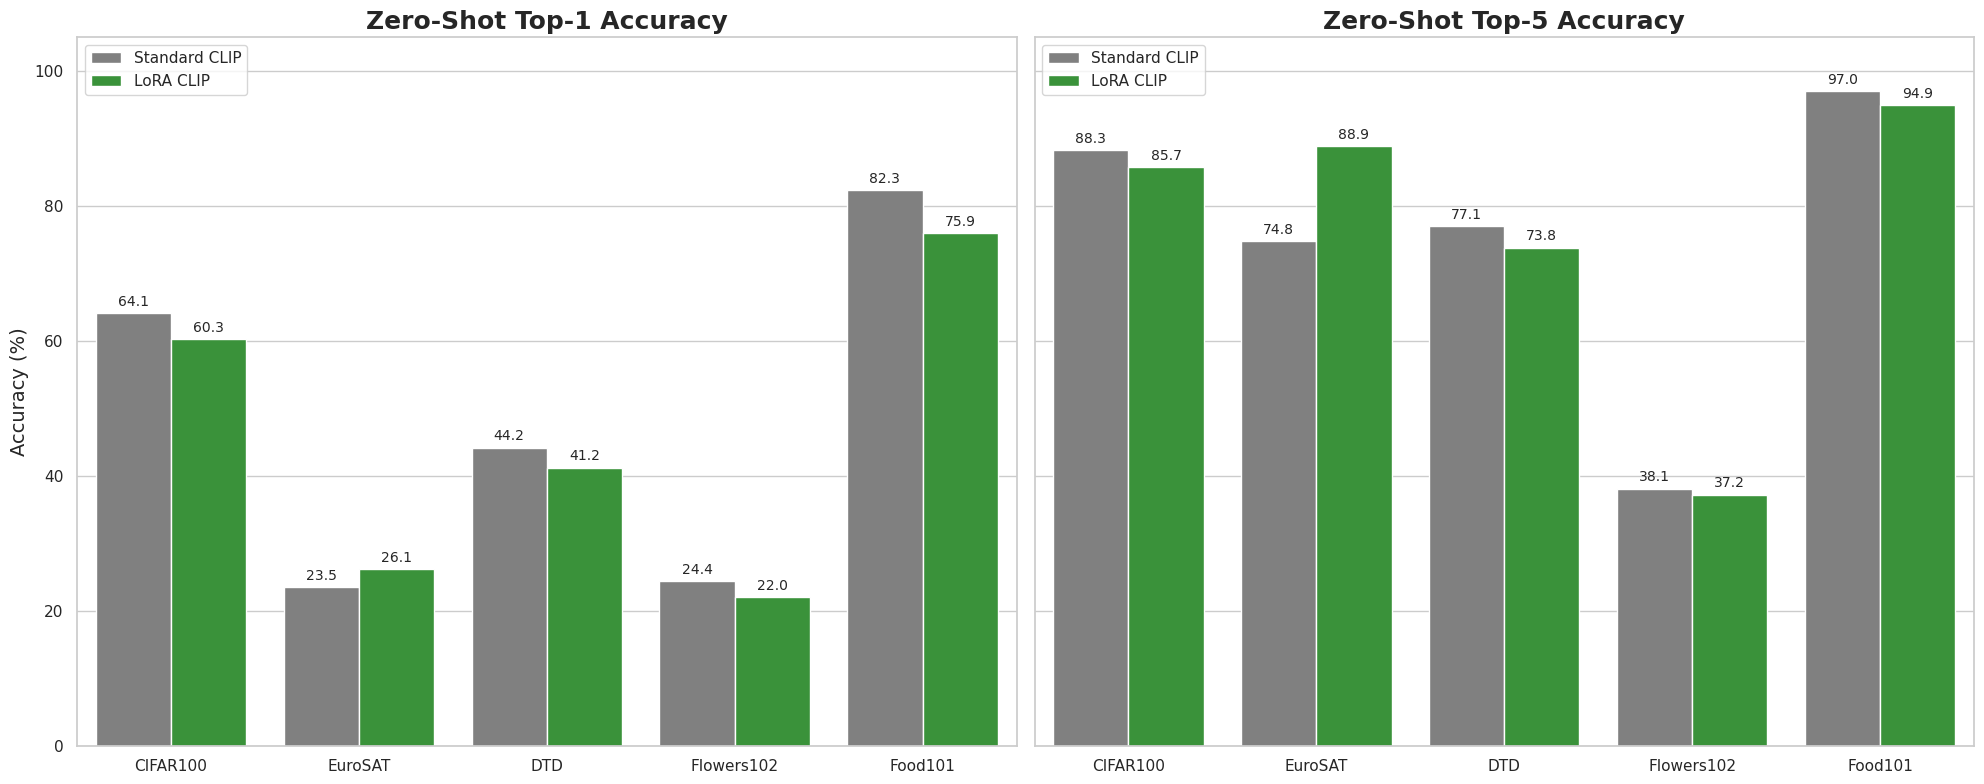

Final summary plot saved to: Results/FINAL_SUMMARY_COMPARISON.png


In [7]:
# --- GENERATE FINAL SUMMARY PLOTS ---

# Convert to Pandas DataFrame for easier plotting
# We reshape the data so "Metric" (Top-1 vs Top-5) becomes a column
plot_data = []
for entry in all_results_data:
    plot_data.append({
        "Dataset": entry["Dataset"],
        "Model": entry["Model"],
        "Metric": "Top-1 Accuracy",
        "Accuracy": entry["Top-1"]
    })
    plot_data.append({
        "Dataset": entry["Dataset"],
        "Model": entry["Model"],
        "Metric": "Top-5 Accuracy",
        "Accuracy": entry["Top-5"]
    })

df = pd.DataFrame(plot_data)

# Set plot style
sns.set_theme(style="whitegrid")

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# --- Plot 1: Top-1 Accuracy ---
sns.barplot(
    data=df[df['Metric'] == "Top-1 Accuracy"],
    x="Dataset", 
    y="Accuracy", 
    hue="Model",
    palette=["gray", "#2ca02c"], # Standard CLIP (Gray), LoRA (Green)
    ax=axes[0]
)
axes[0].set_title("Zero-Shot Top-1 Accuracy", fontsize=18, weight='bold')
axes[0].set_ylabel("Accuracy (%)", fontsize=14)
axes[0].set_xlabel("")
axes[0].set_ylim(0, 105)
axes[0].legend(loc='upper left')

# Add value labels on bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', padding=3, fontsize=10)

# --- Plot 2: Top-5 Accuracy ---
sns.barplot(
    data=df[df['Metric'] == "Top-5 Accuracy"],
    x="Dataset", 
    y="Accuracy", 
    hue="Model",
    palette=["gray", "#2ca02c"],
    ax=axes[1]
)
axes[1].set_title("Zero-Shot Top-5 Accuracy", fontsize=18, weight='bold')
axes[1].set_ylabel("") # Share Y-label with left plot
axes[1].set_xlabel("")
axes[1].set_ylim(0, 105)
axes[1].legend(loc='upper left')

# Add value labels on bars
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f', padding=3, fontsize=10)

# Final Adjustments
plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, "FINAL_SUMMARY_COMPARISON.png")
plt.savefig(save_path, dpi=300)
plt.show()

print(f"Final summary plot saved to: {save_path}")

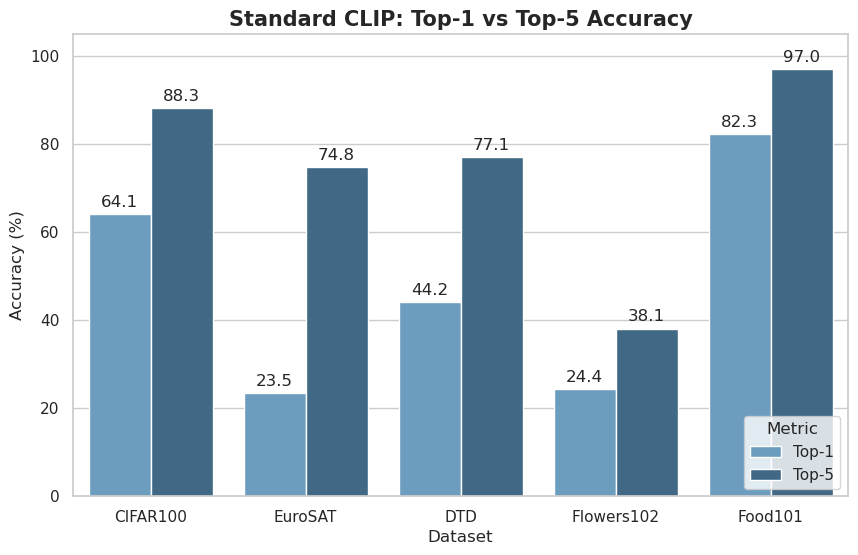

Saved Standard CLIP plot to: Results/Standard_CLIP_Performance.png


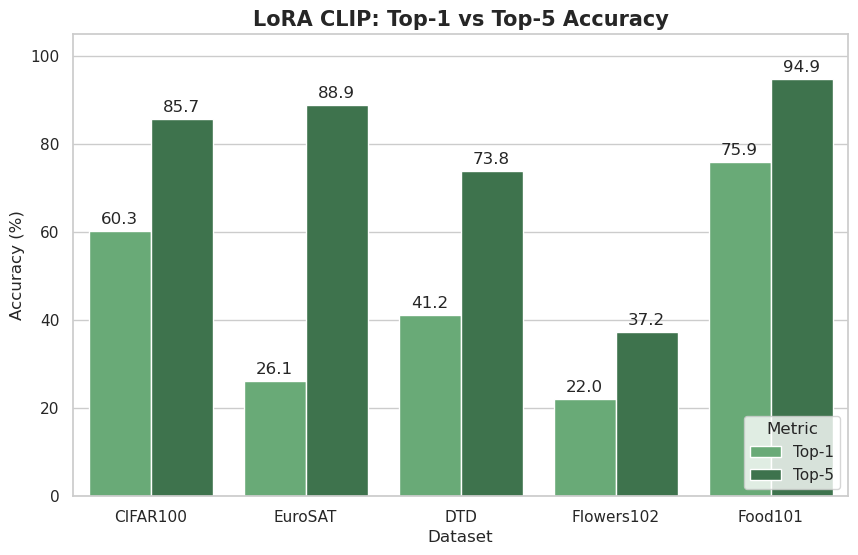

Saved LoRA CLIP plot to: Results/LoRA_CLIP_Performance.png


: 

In [21]:
# --- Configuration ---
RESULTS_DIR = "Results"
JSON_FILENAME = "evaluation_results.json"
FILE_PATH = os.path.join(RESULTS_DIR, JSON_FILENAME)

def load_and_plot():
    # 1. Load the JSON data
    if not os.path.exists(FILE_PATH):
        print(f"Error: File not found at {FILE_PATH}")
        # Fallback for demonstration if file doesn't exist in this run
        # (You can remove this block if running locally with the file)
        print("Using embedded data for demonstration...")
        data = [
            {"Dataset": "CIFAR100", "Model": "Standard CLIP", "Top-1": 64.13, "Top-5": 88.28},
            {"Dataset": "CIFAR100", "Model": "LoRA CLIP", "Top-1": 60.26, "Top-5": 85.74},
            {"Dataset": "EuroSAT", "Model": "Standard CLIP", "Top-1": 23.54, "Top-5": 74.83},
            {"Dataset": "EuroSAT", "Model": "LoRA CLIP", "Top-1": 26.13, "Top-5": 88.91},
            {"Dataset": "DTD", "Model": "Standard CLIP", "Top-1": 44.20, "Top-5": 77.07},
            {"Dataset": "DTD", "Model": "LoRA CLIP", "Top-1": 41.22, "Top-5": 73.83},
            {"Dataset": "Flowers102", "Model": "Standard CLIP", "Top-1": 24.38, "Top-5": 38.12},
            {"Dataset": "Flowers102", "Model": "LoRA CLIP", "Top-1": 22.02, "Top-5": 37.23},
            {"Dataset": "Food101", "Model": "Standard CLIP", "Top-1": 82.35, "Top-5": 97.02},
            {"Dataset": "Food101", "Model": "LoRA CLIP", "Top-1": 75.93, "Top-5": 94.90}
        ]
    else:
        with open(FILE_PATH, 'r') as f:
            data = json.load(f)

    # 2. Process Data into DataFrame
    # We 'melt' the data to have a 'Metric' column (Top-1 or Top-5)
    processed_data = []
    for entry in data:
        processed_data.append({
            "Dataset": entry["Dataset"],
            "Model": entry["Model"],
            "Metric": "Top-1",
            "Accuracy": entry["Top-1"]
        })
        processed_data.append({
            "Dataset": entry["Dataset"],
            "Model": entry["Model"],
            "Metric": "Top-5",
            "Accuracy": entry["Top-5"]
        })
    
    df = pd.DataFrame(processed_data)

    # 3. Create Separate Plots
    sns.set_theme(style="whitegrid")
    
    #Filter for each model
    df_clip = df[df['Model'] == "Standard CLIP"]
    df_lora = df[df['Model'] == "LoRA CLIP"]

    # --- Plot 1: Standard CLIP ---
    plt.figure(figsize=(10, 6))
    ax1 = sns.barplot(
        data=df_clip,
        x="Dataset",
        y="Accuracy",
        hue="Metric",
        palette="Blues_d" 
    )
    plt.title("Standard CLIP: Top-1 vs Top-5 Accuracy", fontsize=15, weight='bold')
    plt.ylim(0, 105)
    plt.ylabel("Accuracy (%)")
    plt.xlabel("Dataset")
    plt.legend(title="Metric", loc='lower right')
    
    # Add labels
    for container in ax1.containers:
        ax1.bar_label(container, fmt='%.1f', padding=3)
    
    # Save and Show
    save_path_clip = os.path.join(RESULTS_DIR, "Standard_CLIP_Performance.png")
    plt.savefig(save_path_clip, dpi=300)
    plt.show()
    print(f"Saved Standard CLIP plot to: {save_path_clip}")

    # --- Plot 2: LoRA CLIP ---
    plt.figure(figsize=(10, 6))
    ax2 = sns.barplot(
        data=df_lora,
        x="Dataset",
        y="Accuracy",
        hue="Metric",
        palette="Greens_d"
    )
    plt.title("LoRA CLIP: Top-1 vs Top-5 Accuracy", fontsize=15, weight='bold')
    plt.ylim(0, 105)
    plt.ylabel("Accuracy (%)")
    plt.xlabel("Dataset")
    plt.legend(title="Metric", loc='lower right')
    
    # Add labels
    for container in ax2.containers:
        ax2.bar_label(container, fmt='%.1f', padding=3)
        
    # Save and Show
    save_path_lora = os.path.join(RESULTS_DIR, "LoRA_CLIP_Performance.png")
    plt.savefig(save_path_lora, dpi=300)
    plt.show()
    print(f"Saved LoRA CLIP plot to: {save_path_lora}")

if __name__ == "__main__":
    # Ensure output directory exists
    os.makedirs(RESULTS_DIR, exist_ok=True)
    load_and_plot()